In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Import dataset

In [2]:
prices = pd.read_parquet("../data/processed/stock_prices_clean.parquet")

## 2. Average trading volume

Which assets were most frequently traded over the observation period?

<Axes: title={'center': 'Average Daily Trading Volume by Asset'}, xlabel='ticker'>

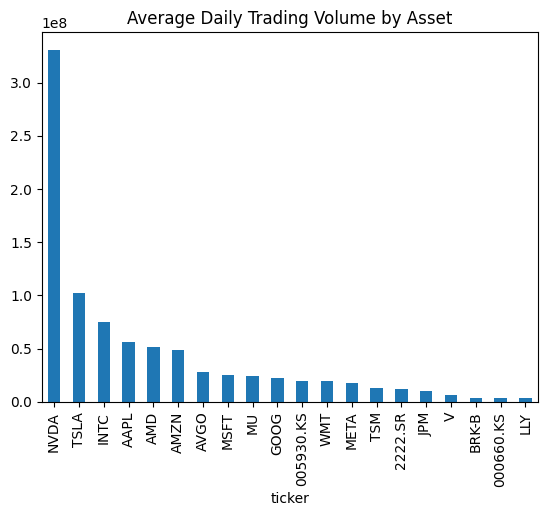

In [3]:
average_volume = (
    prices.groupby("ticker")["volume"]
    .mean()
    .sort_values(ascending=False)
)
average_volume.plot(
    kind="bar",
    title="Average Daily Trading Volume by Asset")

## 3. Cumulative returns

Which assets performed best over the entire observation period?

In [4]:
pivot_prices = prices.pivot(
    index="date",
    columns="ticker",
    values="close"
)

C:\Users\elton\AppData\Local\Temp\ipykernel_58200\725211349.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = pivot_prices.pct_change()


<Axes: title={'center': 'Cumulative Returns'}, xlabel='date'>

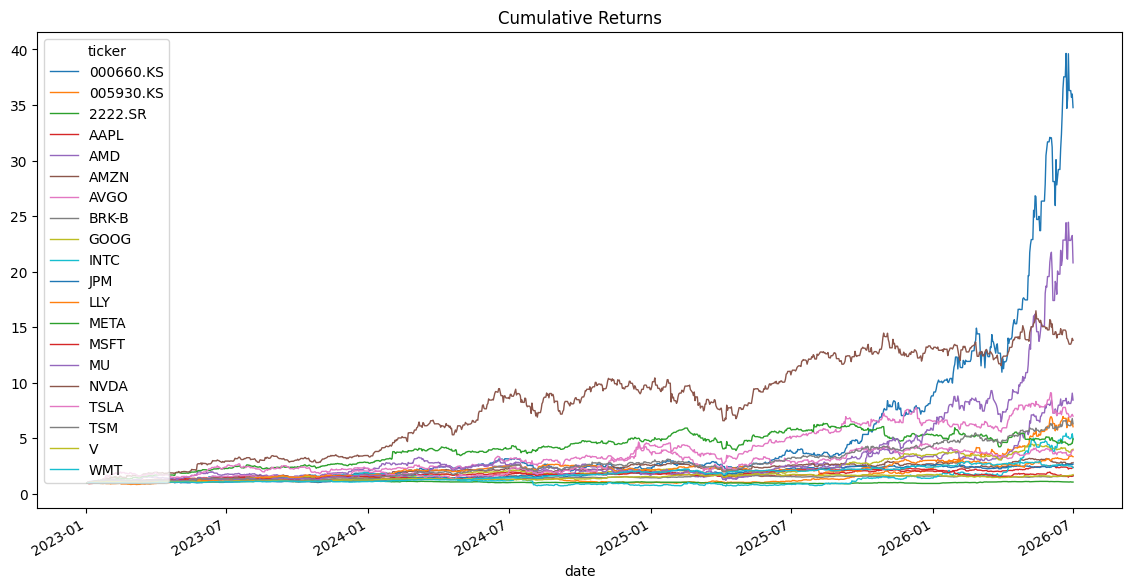

In [5]:
returns = pivot_prices.pct_change()

cumulative_returns = (
    1 + returns
).cumprod()

cumulative_returns.plot(
    figsize=(14,7),
    title="Cumulative Returns",
    linewidth=1
)

## 4. Distribution of daily returns

<Axes: xlabel='ticker'>

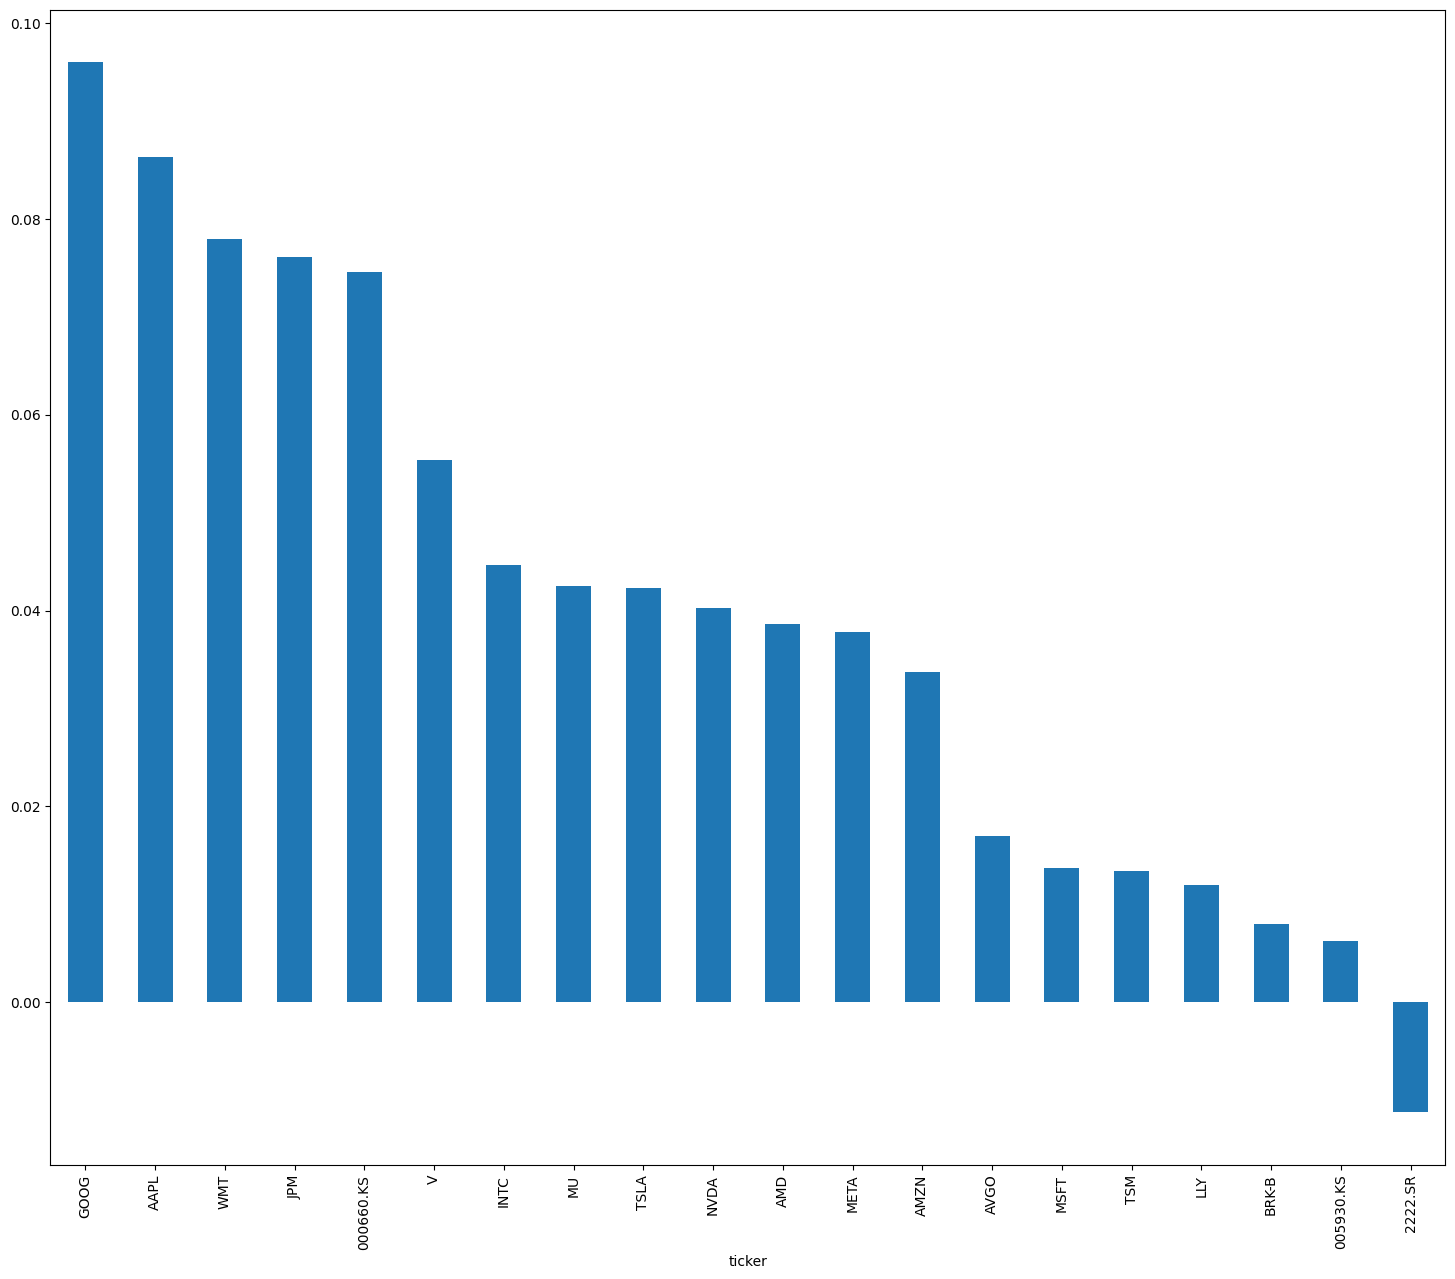

In [6]:
performance = (
    prices.groupby("ticker")
    .agg(
        avg_return=("daily_return","mean"),
        volatility=("daily_return","std")
    )
)

performance["return_to_volatility_ratio"] = (
    performance["avg_return"] /
    performance["volatility"]
)

performance = performance.sort_values(
    "return_to_volatility_ratio",
    ascending=False
)
performance["return_to_volatility_ratio"].plot.bar(figsize=(18,15))

## 5. Return boxplots

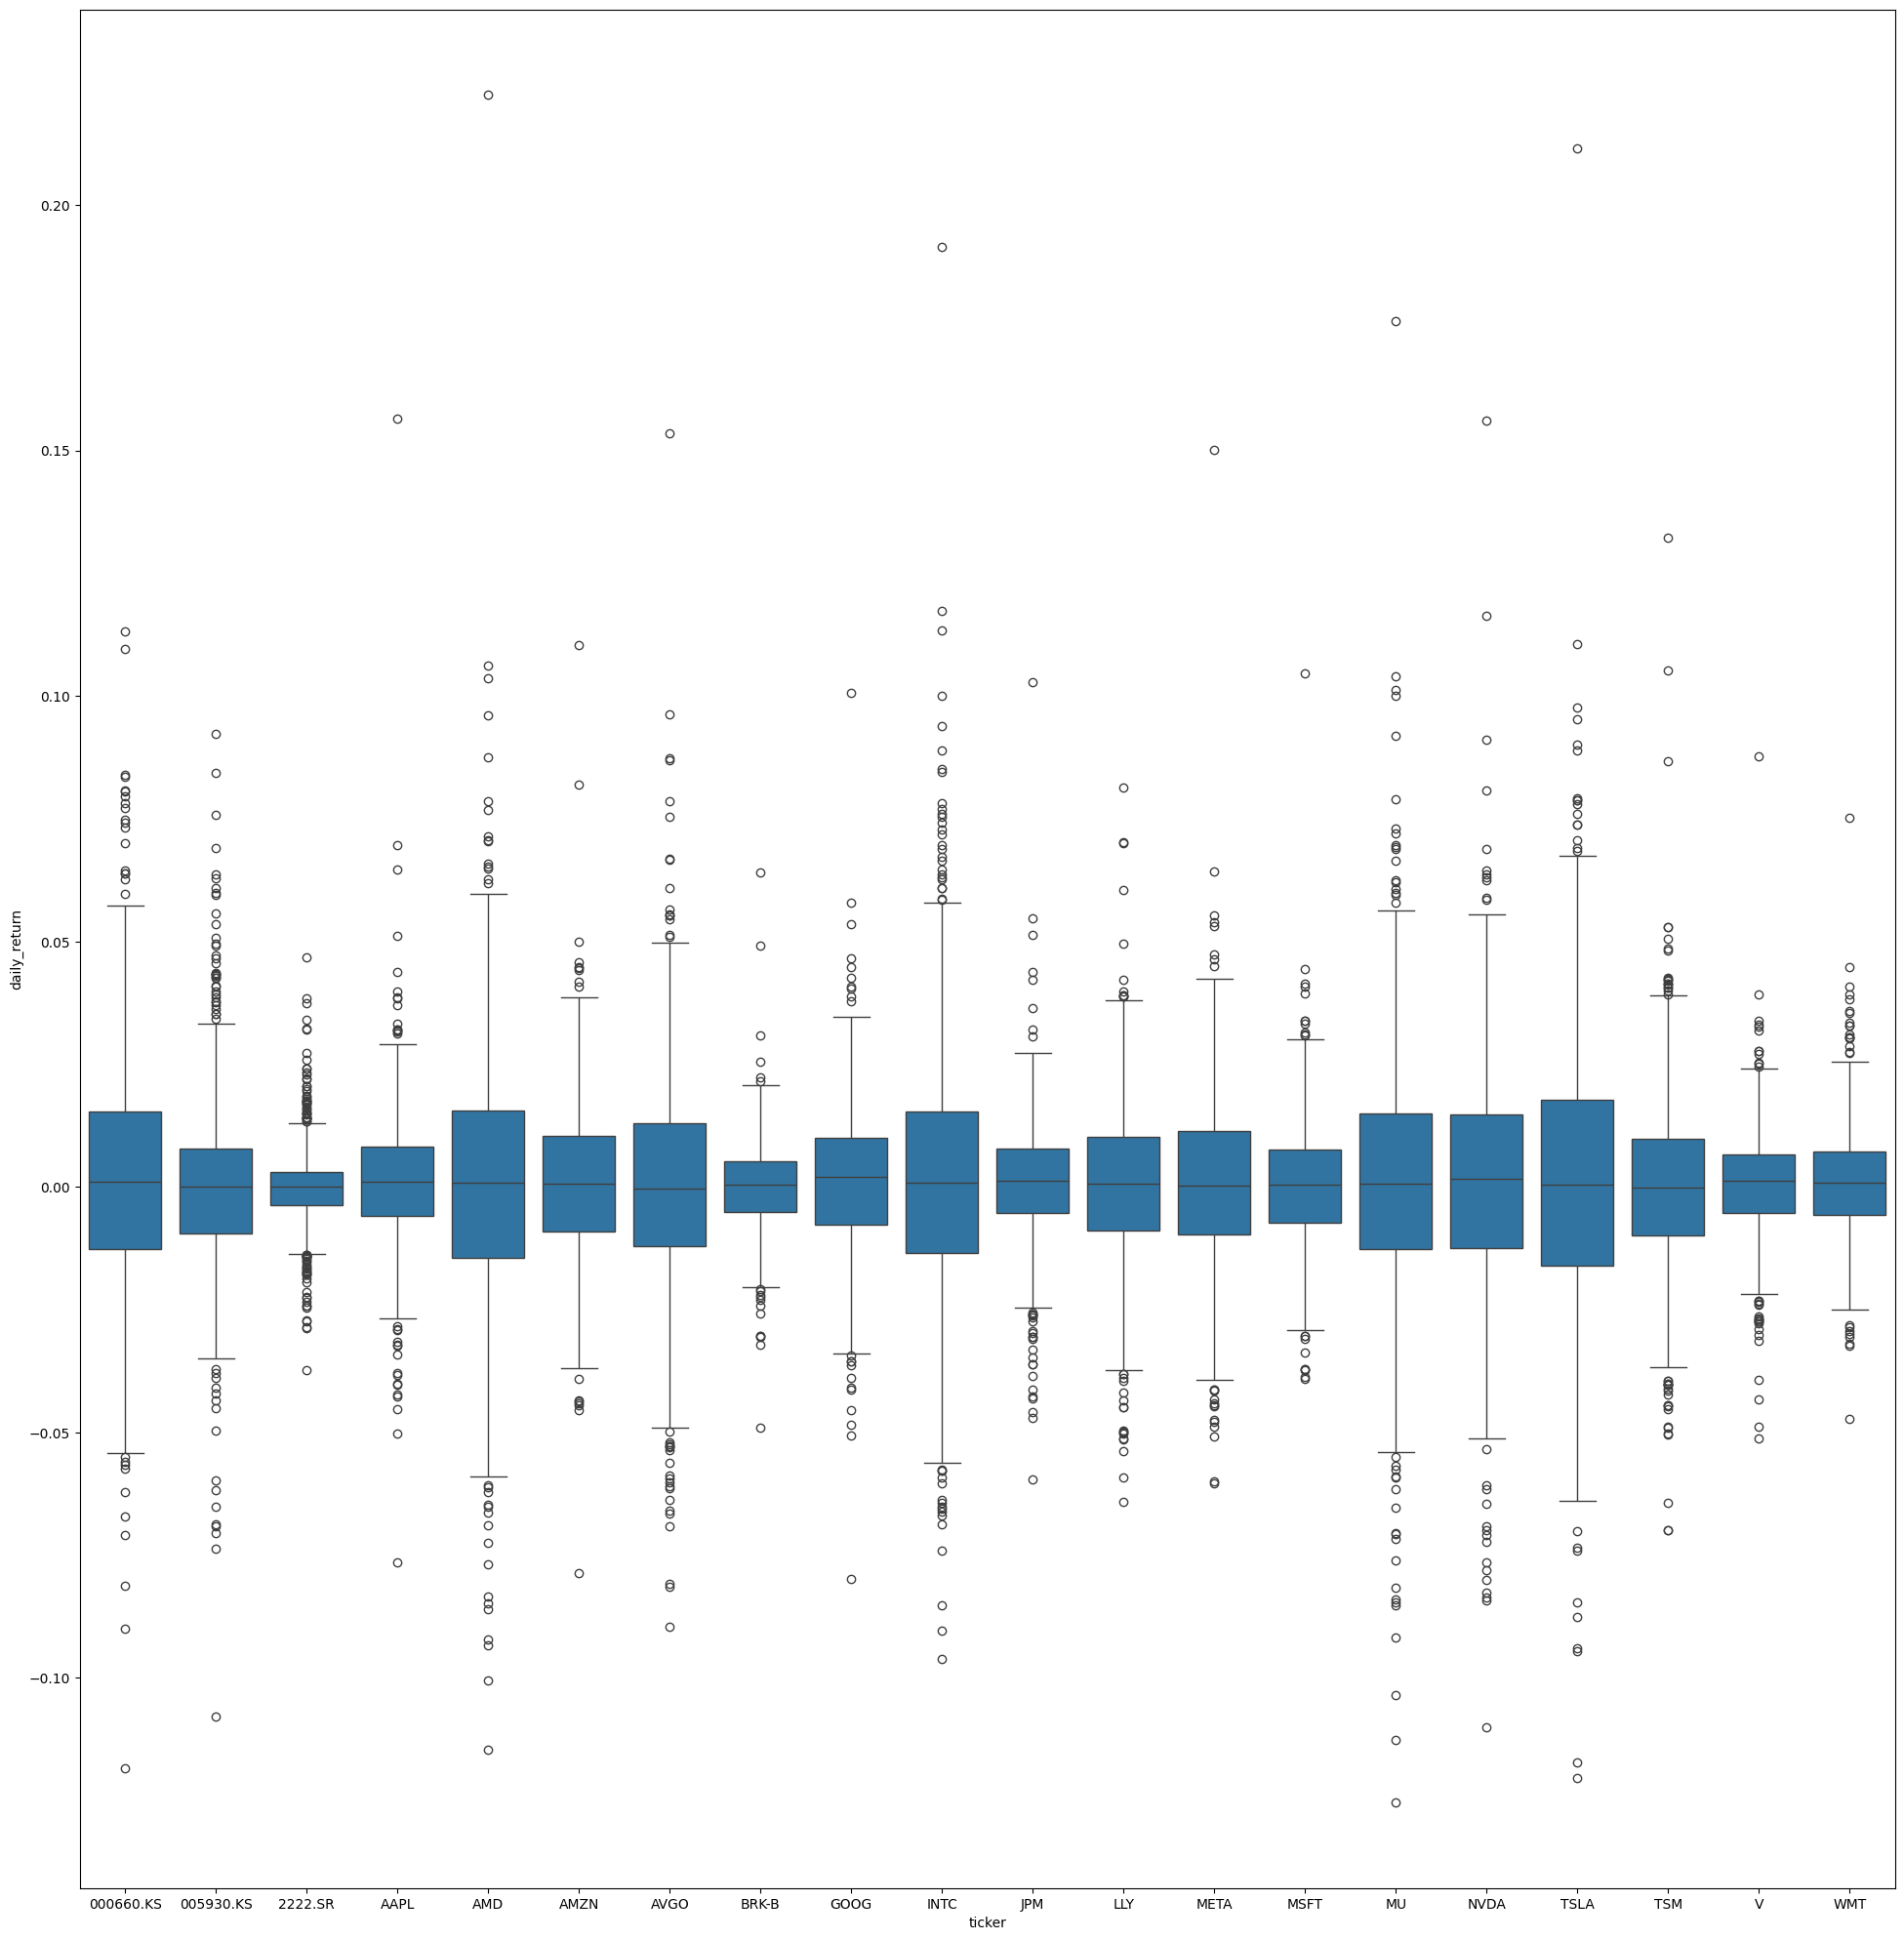

In [7]:
fig, ax = plt.subplots(figsize=(24, 25))
sns.boxplot(
    data=prices,
    x="ticker",
    y="daily_return"
)
plt.show()

## 6. Average Rolling Volatility

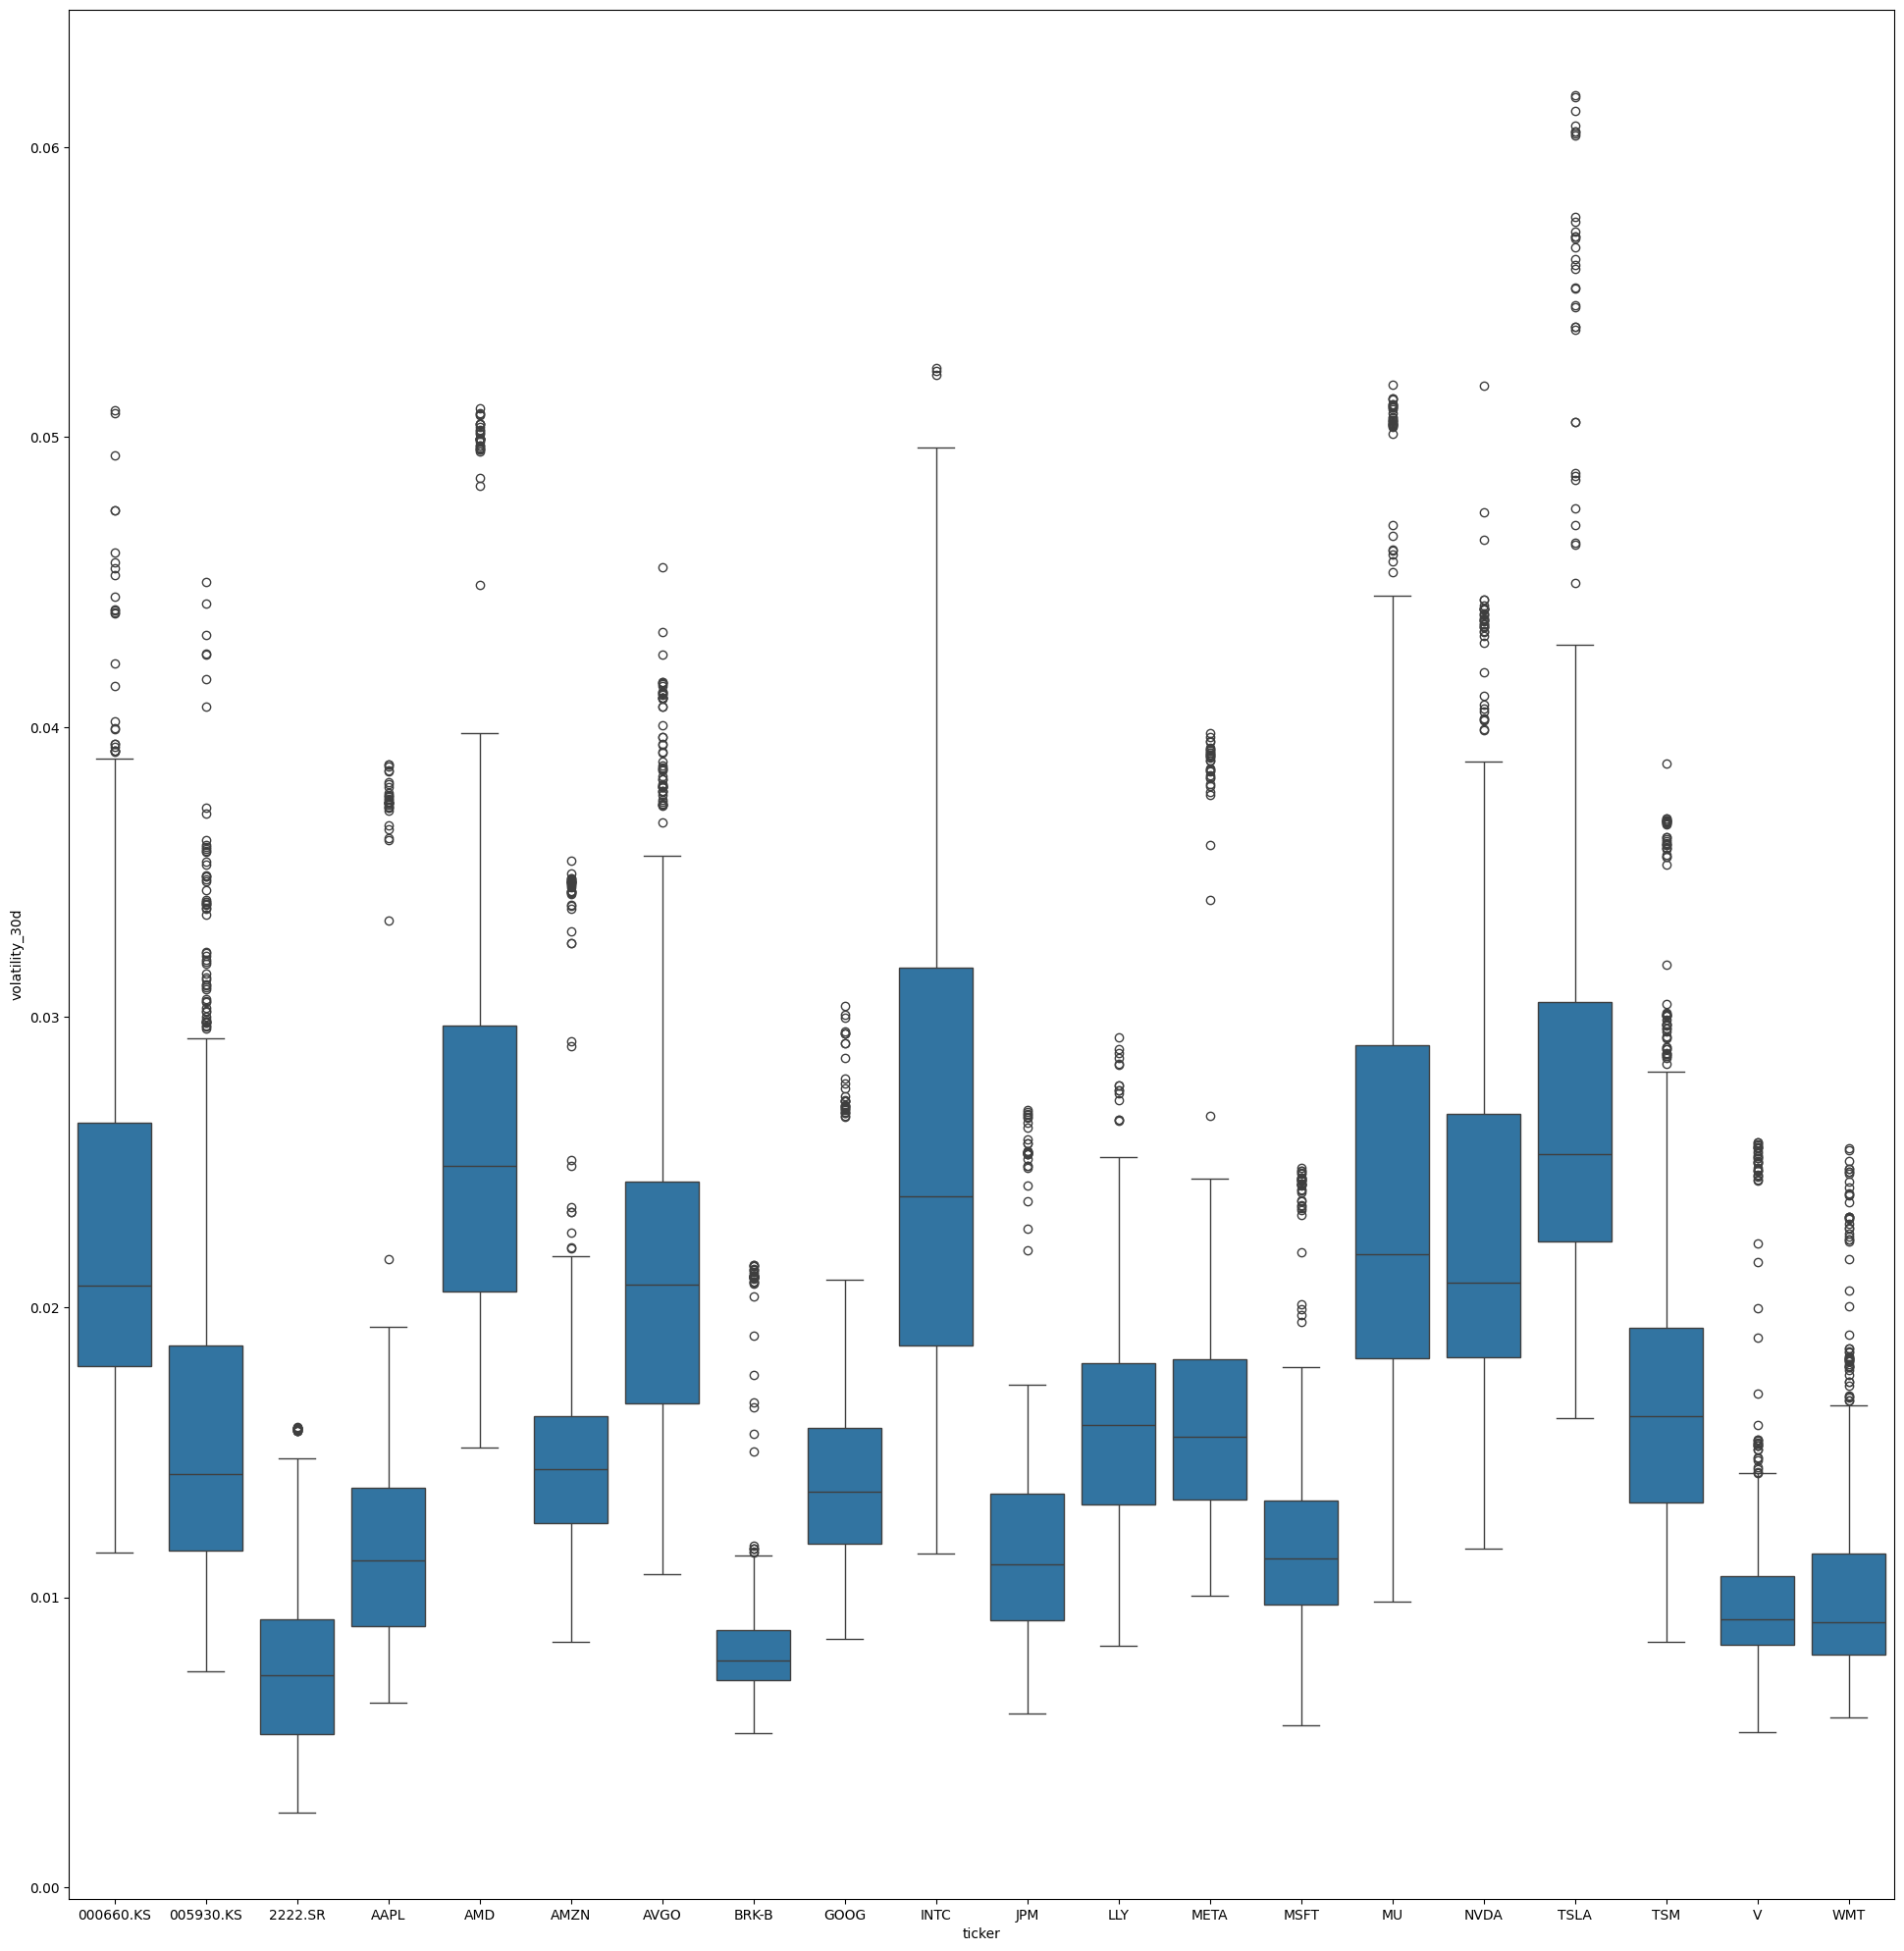

In [8]:
fig, ax = plt.subplots(figsize=(24, 25))
sns.boxplot(
    data=prices,
    x="ticker",
    y="volatility_30d"
)
plt.show()

NVDA exhibited the highest average rolling volatility, suggesting substantially larger day-to-day price fluctuations than the remaining assets.

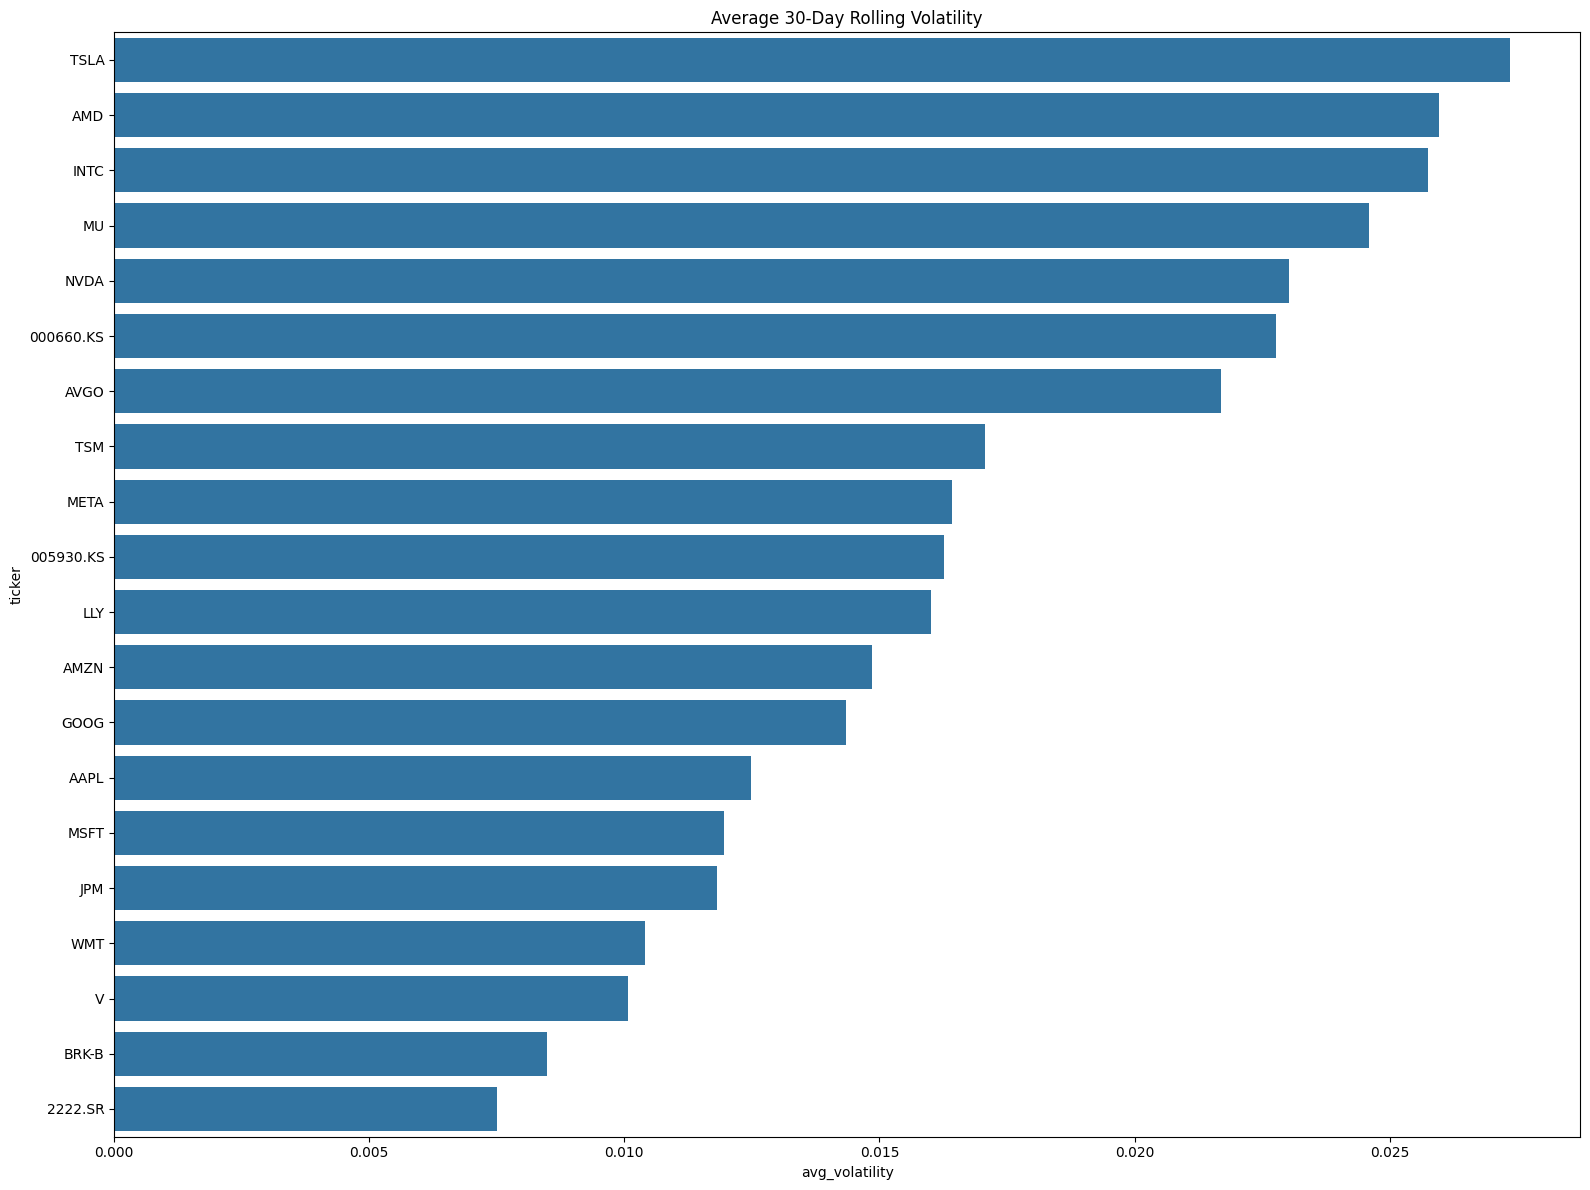

In [9]:
volatility = (
    prices.groupby("ticker", as_index=False)
    .agg(avg_volatility=("volatility_30d", "mean"))
    .sort_values("avg_volatility", ascending=False)
)

fig, ax = plt.subplots(figsize=(16, 12))

sns.barplot(
    data=volatility,
    x="avg_volatility",
    y="ticker",
    order=volatility["ticker"],
    ax=ax
)

ax.set_title("Average 30-Day Rolling Volatility")
plt.tight_layout()
plt.show()

## 7. Drawdown Ranking

In [10]:
order = (
    prices.groupby("ticker")["drawdown"]
    .min()
    .sort_values()
    .index
)

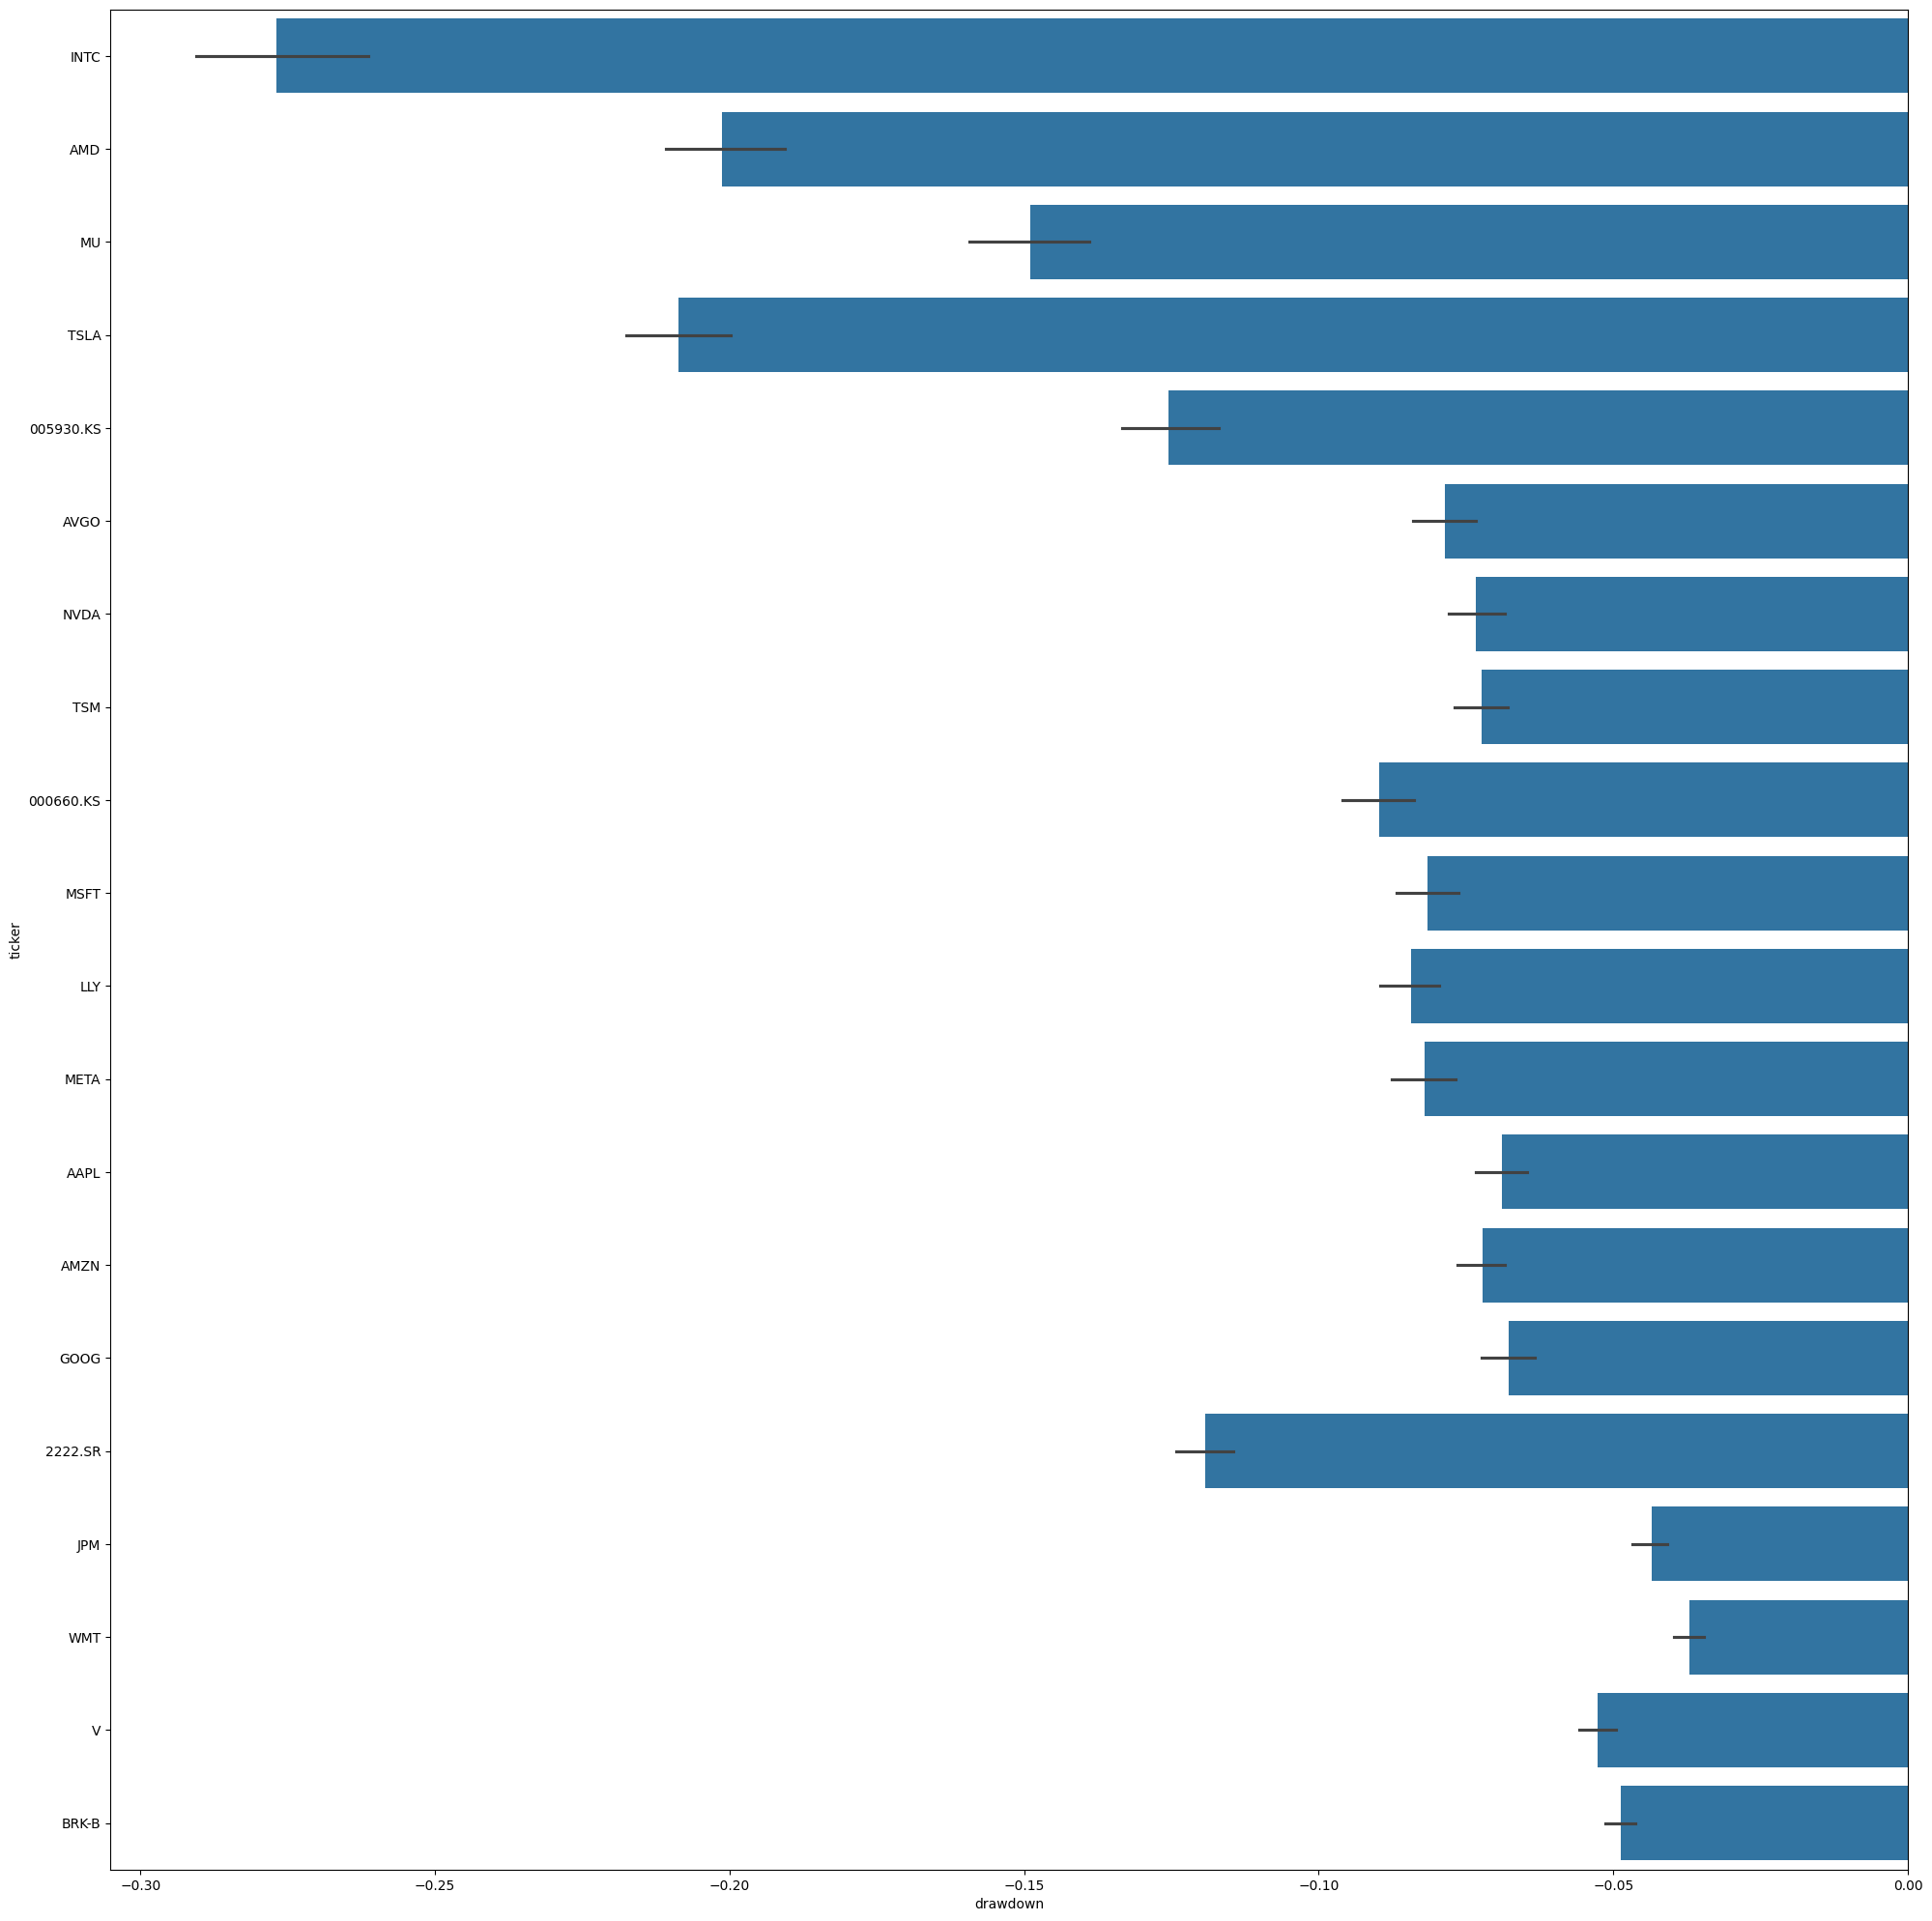

In [11]:
fig, ax = plt.subplots(figsize=(24, 25))
sns.barplot(
    data=prices,
    x="drawdown",
    y="ticker",
    order=order
)
plt.show()

## 8. Risk versus Return

Which stock offered the best return for the amount of risk taken?

In [12]:
risk_return = (
    prices.groupby("ticker")
    .agg(
        avg_volatility=("volatility_30d", "mean"),
        final_return=("cumulative_return", "last"),
        max_drawdown=("drawdown", "min")
    )
    .reset_index()
)

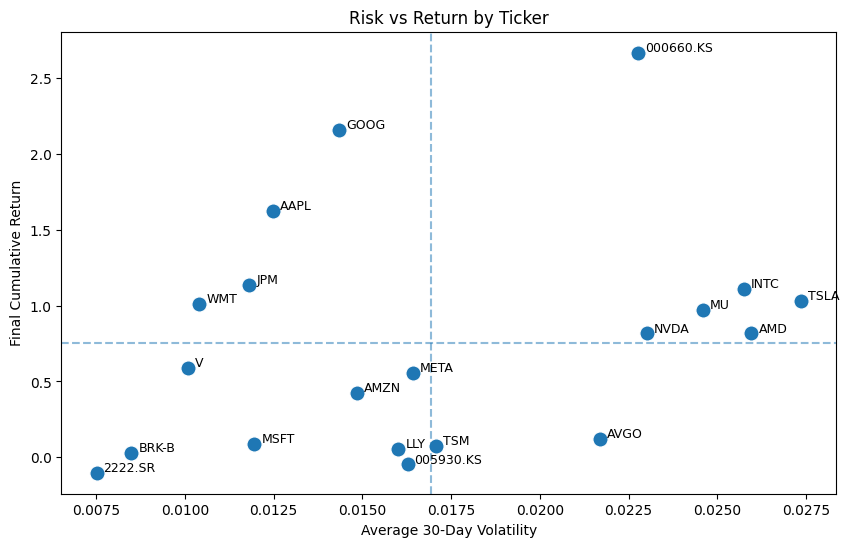

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=risk_return,
    x="avg_volatility",
    y="final_return",
    s=120
)

for _, row in risk_return.iterrows():
    plt.text(
        row["avg_volatility"] + 0.0002,
        row["final_return"] + 0.01,
        row["ticker"],
        fontsize=9
    )

plt.xlabel("Average 30-Day Volatility")
plt.ylabel("Final Cumulative Return")
plt.title("Risk vs Return by Ticker")

plt.axhline(
    risk_return["final_return"].mean(),
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    risk_return["avg_volatility"].mean(),
    linestyle="--",
    alpha=0.5
)

plt.show()

## 9. Correlation Heatmap

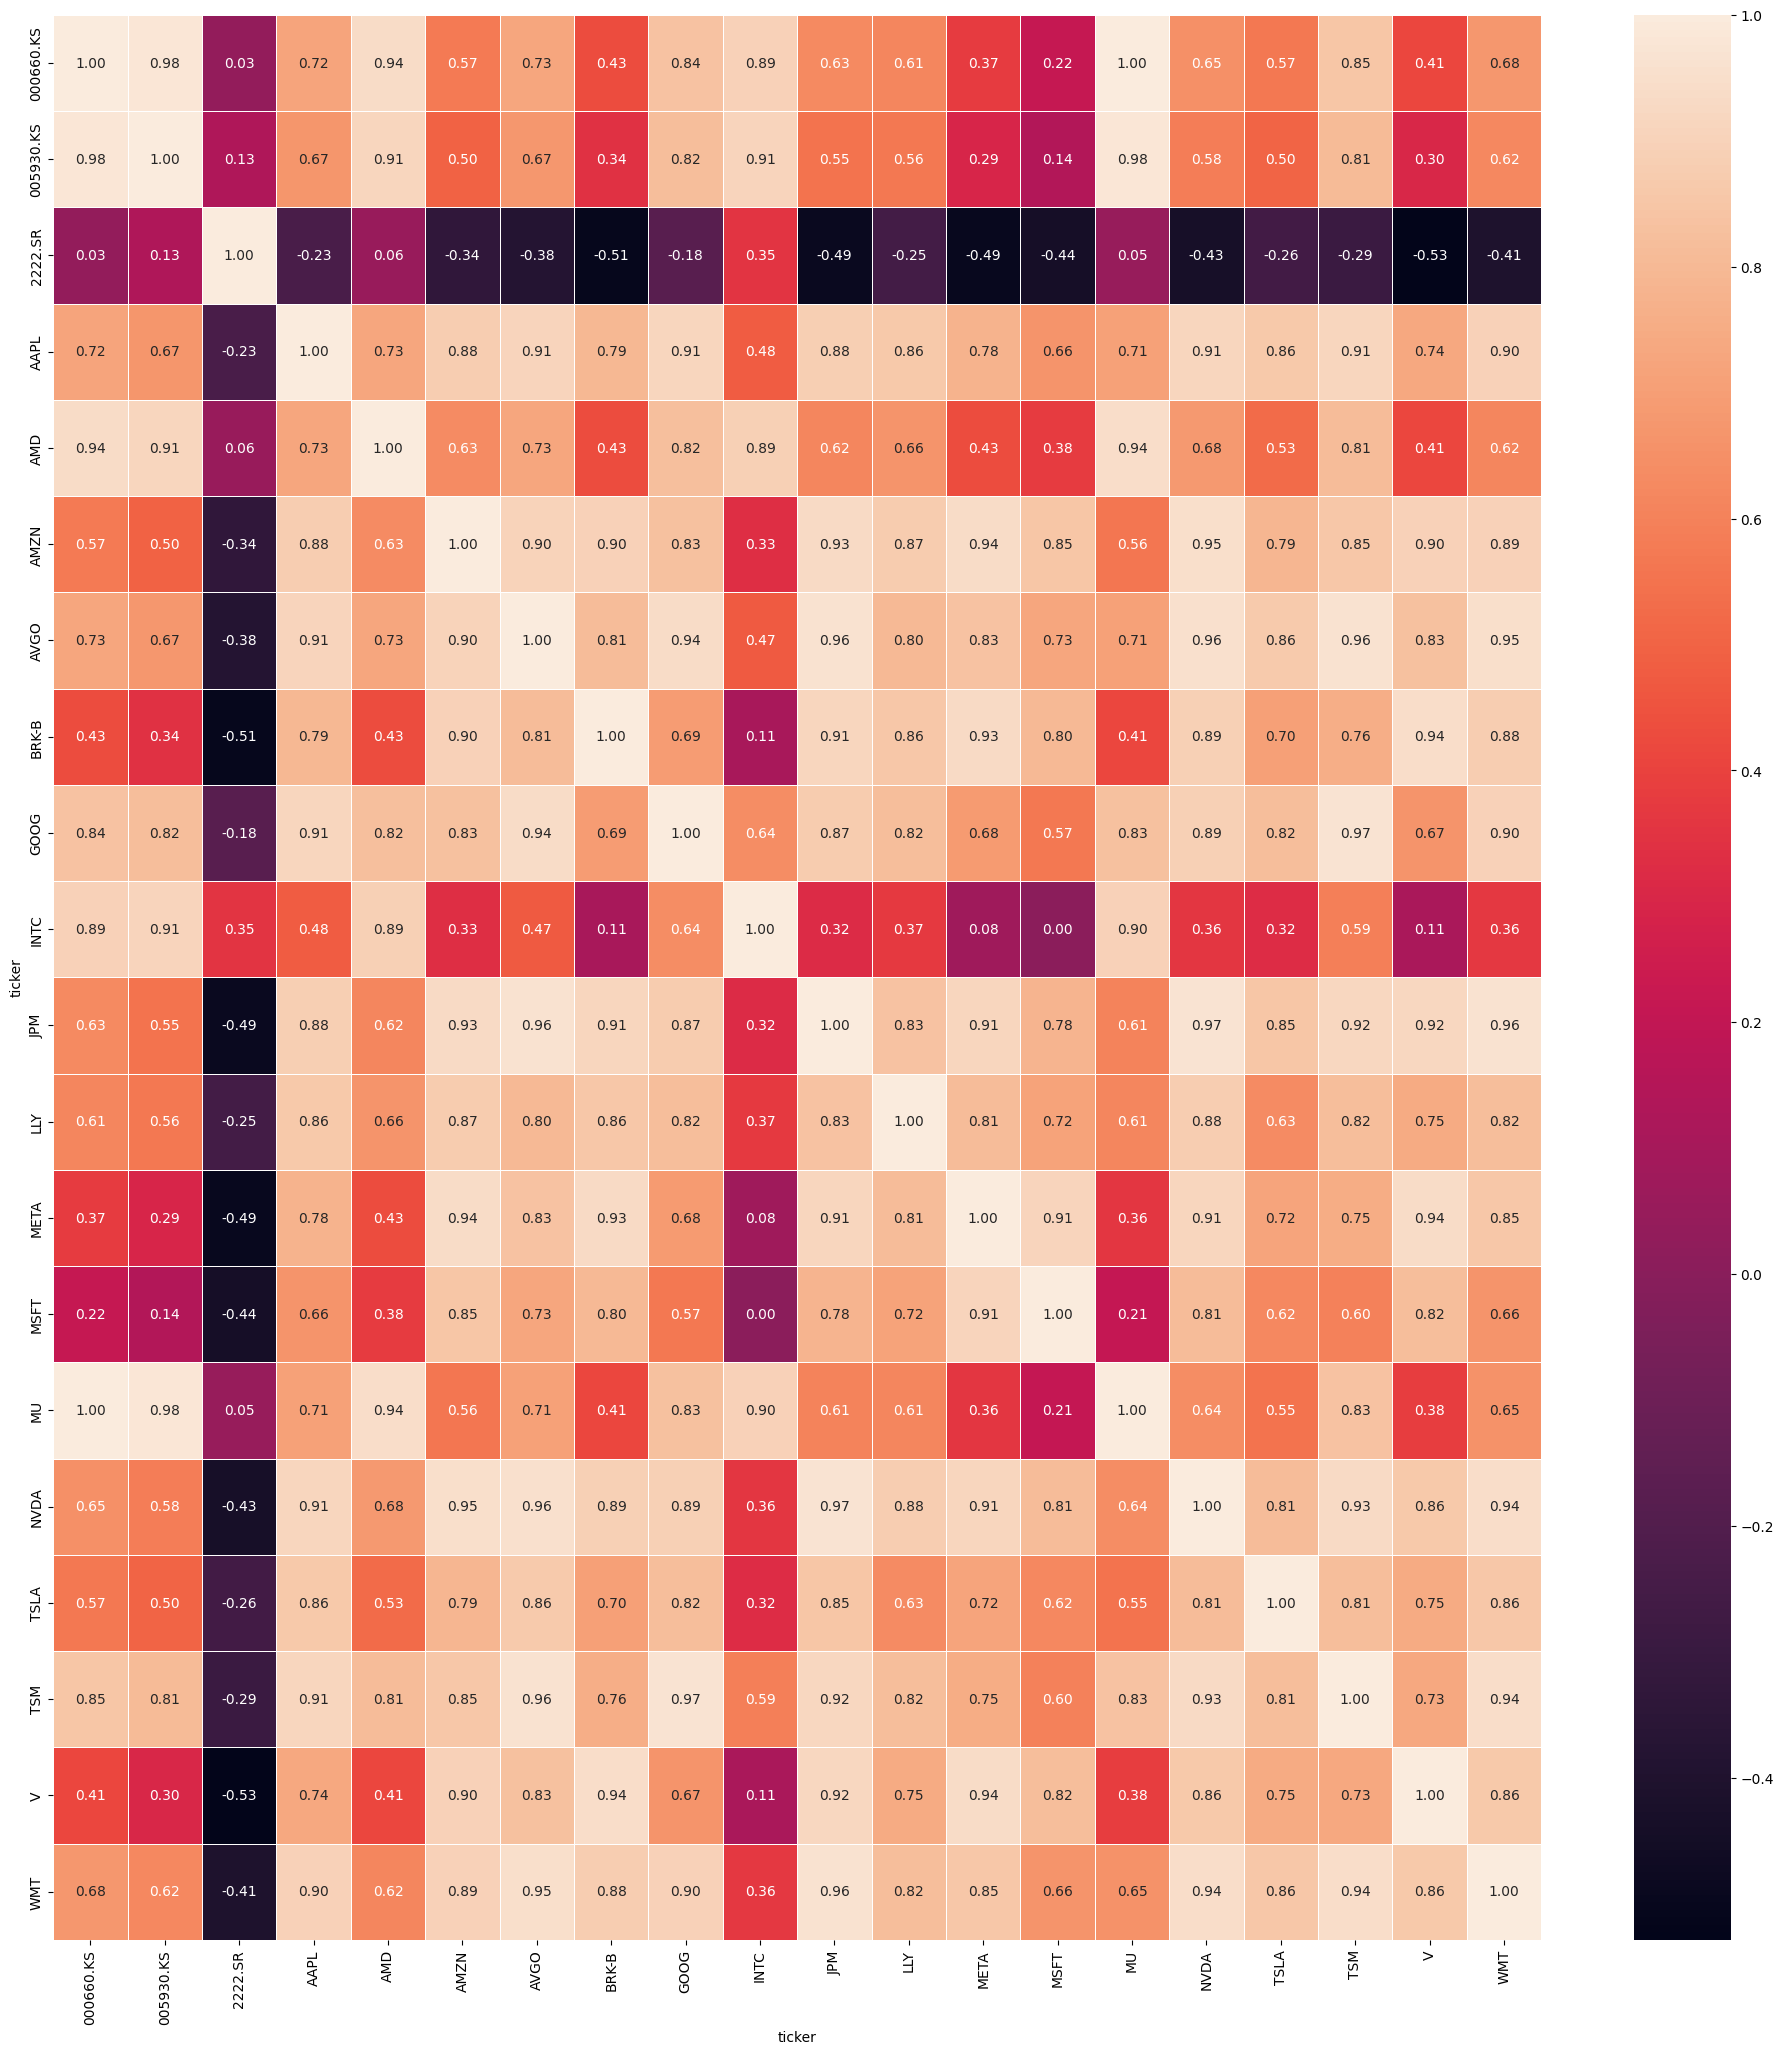

In [14]:
def check_correlation(df):
    fig, ax = plt.subplots(figsize=(24, 25))
    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidth=0.5)
    plt.show()

check_correlation(pivot_prices)

# 10. Business summary table

In [15]:
def summary_table(df):
    summary = (
        df.groupby("ticker")
        .agg(
            total_return=("cumulative_return", "last"),
            avg_volatility=("volatility_30d", "mean"),
            return_to_volatility_ratio=("daily_return", lambda x: x.mean() / x.std() if x.std() != 0 else np.nan),
            drawdown=("drawdown", "min"),
            
        )
        .reset_index()
    )
    return summary

In [16]:
def overall_assessment(row, df):
    median_return = df["total_return"].median()
    median_volatility = df["avg_volatility"].median()

    if (row["total_return"] >= median_return and row["avg_volatility"] >= median_volatility):
        return "High Return / High Risk"

    if (row["total_return"] >= median_return and row["avg_volatility"] < median_volatility):
        return "Efficient Performer"

    if (row["total_return"] < median_return and row["avg_volatility"] < median_volatility):
        return "Stable"

    return "Weak Risk-Reward"

In [17]:
summary = summary_table(prices)

In [18]:
summary["overall_assessment"] = summary.apply(
    overall_assessment,
    axis=1,
    df=summary
)

In [19]:
summary["total_return"] = (
    summary["total_return"] * 100
).round(2).astype(str) + "%"

summary["avg_volatility"] = (
    summary["avg_volatility"] * 100
).round(2).astype(str) + "%"

summary["drawdown"] = (
    summary["drawdown"] * 100
).round(2).astype(str) + "%"

summary["return_to_volatility_ratio"] = (
    summary["return_to_volatility_ratio"]
).round(2)

### Business Question

Which assets delivered the highest return-adjusted performance over the observation period?

In [20]:
summary

,ticker,total_return,avg_volatility,return_to_volatility_ratio,drawdown,overall_assessment
0,000660.KS,266.7%,2.28%,0.07,-36.6%,High Return / High Risk
1,005930.KS,-4.69%,1.63%,0.01,-42.85%,Weak Risk-Reward
2,2222.SR,-10.16%,0.75%,-0.01,-25.56%,Stable
3,AAPL,162.13%,1.25%,0.09,-33.36%,Efficient Performer
4,AMD,81.65%,2.6%,0.04,-63.0%,High Return / High Risk
5,AMZN,42.71%,1.48%,0.03,-30.88%,Stable
6,AVGO,12.01%,2.17%,0.02,-41.15%,Weak Risk-Reward
7,BRK-B,2.81%,0.85%,0.01,-14.95%,Stable
8,GOOG,215.93%,1.43%,0.10,-29.35%,Efficient Performer
9,INTC,110.9%,2.57%,0.04,-63.8%,High Return / High Risk


During the analysed period, NVIDIA delivered the strongest cumulative return but also exhibited the highest volatility and deepest drawdowns. Microsoft achieved comparatively strong returns with lower risk, while SPY remained the most stable asset, exhibiting the lowest average volatility and relatively shallow maximum drawdowns throughout the observation period. Overall, the engineered financial indicators successfully distinguished between growth-oriented and defensive assets and provided a richer basis for portfolio analysis than raw closing prices alone.

- NVDA delivered the strongest cumulative return but also among the highest volatility.
- Berkshire Hathaway exhibited relatively low volatility with modest returns.
- Japanese and South Korean equities showed different correlation patterns from U.S. technology stocks.
- Several technology stocks clustered in the high-risk, high-return quadrant.
- Correlation analysis indicates limited diversification benefits among large-cap U.S. technology companies.